# B02 — NanoString CosMx Stabl Feature Selection

**Parallel Track B: Human True Single-Cell Spatial (NanoString CosMx)**

This notebook applies the two-stage feature selection pipeline to the
NanoString CosMx single-cell spatial dataset prepared in B01. The
identical Stabl stability-selection approach used for Phase 1 Visium data
is applied here, demonstrating platform-agnostic biomarker discovery.

### Pipeline
1. Load preprocessed NanoString checkpoint from B01
2. Run genome-wide Wilcoxon rank-sum DE baseline (AD vs. Control)
3. Generate Volcano Plot 1: DE significance
4. Run Stabl stability selection on DE-filtered candidates
5. Generate Volcano Plot 2: Stabl-selected biomarkers highlighted

### Inputs
| File | Description |
|---|---|
| `data/processed/nanostring_preprocessed.h5ad` | QC-filtered, normalized NanoString AnnData from B01 |

### Outputs
| File | Description |
|---|---|
| `cache/stabl_results_<hash>.pkl` | Full Stabl result dictionary for NanoString data |
| `cache/stabl_features_<hash>.csv` | Selected genes with stability scores |
| `assets/nanostring_volcano_de.png` | Volcano plot: genome-wide DE |
| `assets/nanostring_volcano_stabl.png` | Volcano plot: DE + Stabl overlay |

In [1]:
import warnings
warnings.filterwarnings("ignore", module="tqdm")

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import load_adata, run_stabl_cached, set_plot_defaults

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"
ASSETS_DIR = PROJECT_ROOT / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports ready.")

Imports ready.


## B2.1 Load Preprocessed NanoString Data

Load the QC-filtered and normalized single-cell AnnData produced by B01.

In [2]:
adata = load_adata(DATA_PROCESSED / "nanostring_preprocessed.h5ad")
print(f"\nLoaded: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Conditions: {dict(adata.obs['condition'].value_counts())}")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/nanostring_preprocessed.h5ad
  Shape: 5000 spots × 960 genes

Loaded: 5000 cells × 960 genes
Conditions: {0: np.int64(2524), 1: np.int64(2476)}


## B2.2 Genome-Wide Differential Expression & Volcano Plot

Wilcoxon rank-sum test across all genes: AD (condition 1) vs. Control
(condition 0) with Benjamini-Hochberg FDR correction. The volcano plot
colours significant genes by direction — **blue** (upregulated in AD)
and **red** (downregulated in AD).

DE results: 5 up  |  0 down  |  955 ns  (total 960)


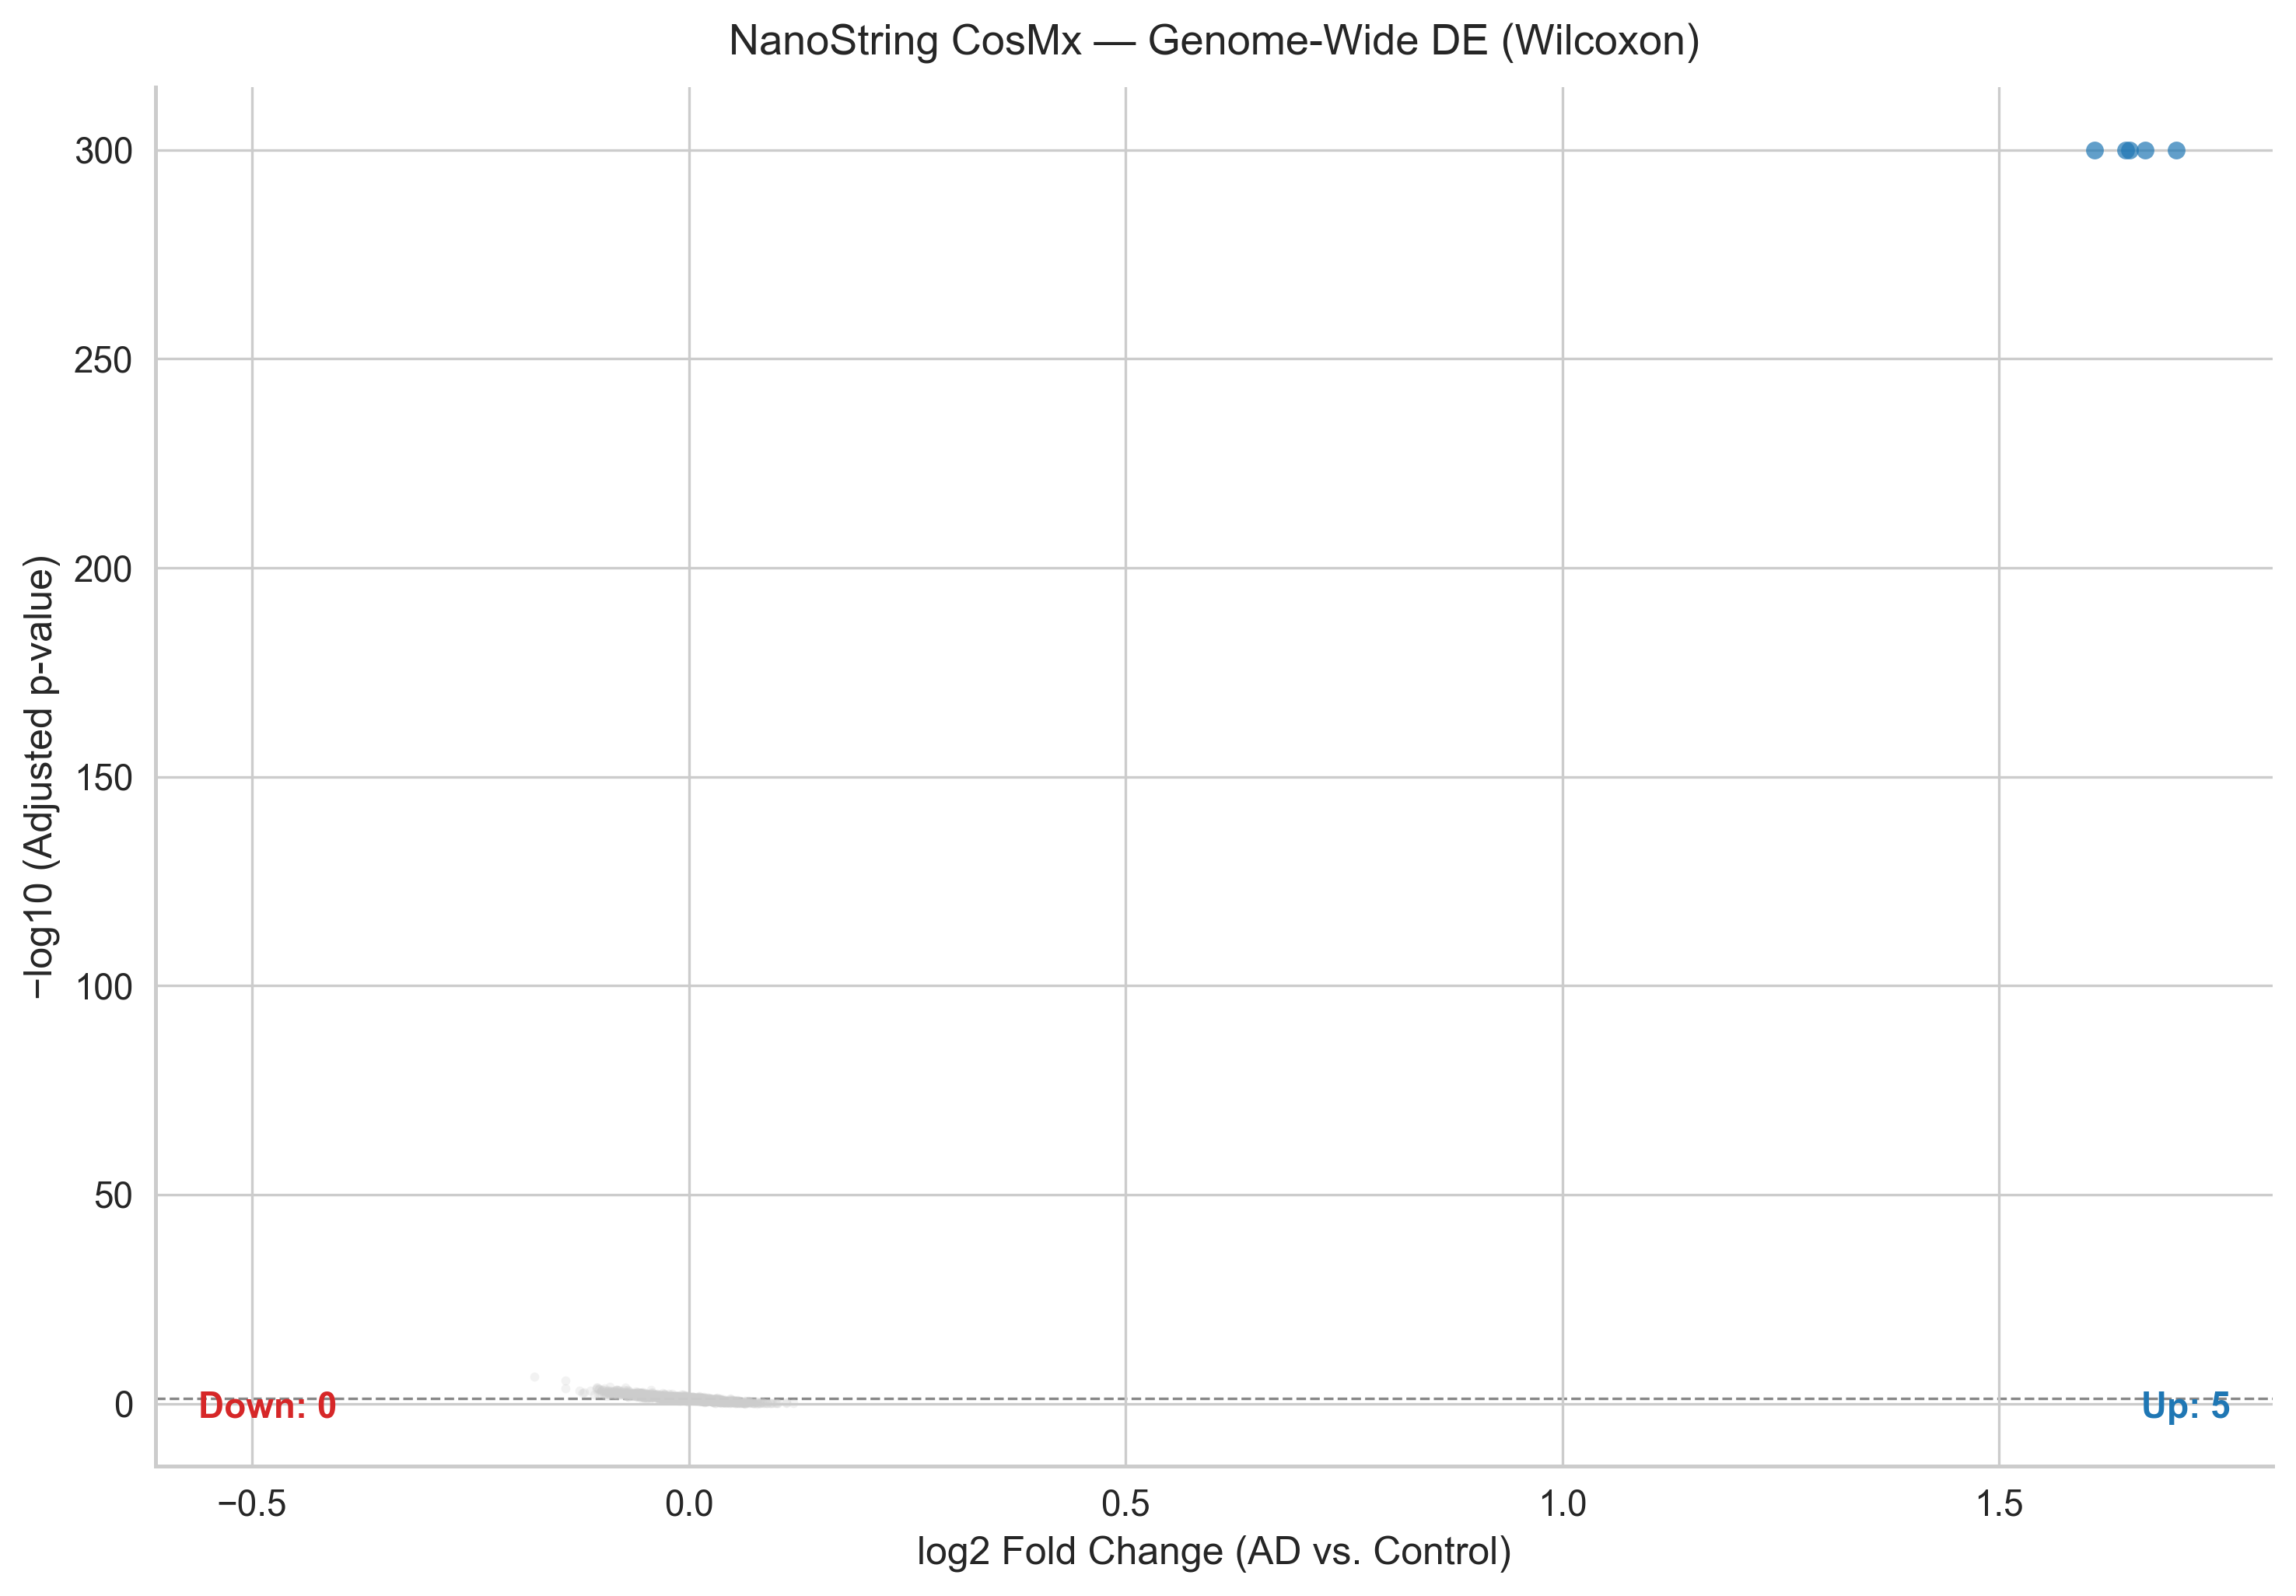

Volcano plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/nanostring_volcano_de.png


In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

set_plot_defaults(fontsize=12, dpi=300)

# Ensure condition is categorical string for scanpy
adata.obs["condition"] = adata.obs["condition"].astype(str).astype("category")

# Wilcoxon DE: AD (1) vs Control (0)
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    groups=["1"],
    reference="0",
    method="wilcoxon",
    key_added="wilcoxon_nanostring",
)

de_df = sc.get.rank_genes_groups_df(adata, group="1", key="wilcoxon_nanostring")
de_df = de_df.rename(
    columns={"names": "gene", "logfoldchanges": "log2FC", "pvals_adj": "pval_adj"}
)
de_df["pval_adj"] = de_df["pval_adj"].clip(lower=1e-300)
de_df["neg_log10_pval"] = -np.log10(de_df["pval_adj"])

# Clean up
del adata.uns["wilcoxon_nanostring"]
import gc; gc.collect()

# Classify genes
FC_THR = 0.5
FDR_THR = 0.05
de_df["sig"] = "ns"
de_df.loc[(de_df["pval_adj"] < FDR_THR) & (de_df["log2FC"] > FC_THR), "sig"] = "up"
de_df.loc[(de_df["pval_adj"] < FDR_THR) & (de_df["log2FC"] < -FC_THR), "sig"] = "down"

n_up = (de_df["sig"] == "up").sum()
n_down = (de_df["sig"] == "down").sum()
n_ns = (de_df["sig"] == "ns").sum()
print(f"DE results: {n_up:,} up  |  {n_down:,} down  |  {n_ns:,} ns  (total {len(de_df):,})")

# ---------- Volcano Plot 1: DE ----------
COLOR_MAP = {"ns": "#CCCCCC", "up": "#1F77B4", "down": "#D62728"}
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

for cat, zorder in [("ns", 1), ("down", 3), ("up", 3)]:
    sub = de_df[de_df["sig"] == cat]
    sz = 8 if cat == "ns" else 30
    alpha = 0.25 if cat == "ns" else 0.7
    ax.scatter(
        sub["log2FC"], sub["neg_log10_pval"],
        s=sz, alpha=alpha, c=COLOR_MAP[cat], linewidths=0, zorder=zorder,
    )

# Reference lines
pval_line = -np.log10(FDR_THR)
ax.axhline(pval_line, color="#888", ls="--", lw=0.8, zorder=0)
ax.axvline(FC_THR, color="#888", ls=":", lw=0.7, zorder=0)
ax.axvline(-FC_THR, color="#888", ls=":", lw=0.7, zorder=0)

# Significance counts
ax.text(0.02, 0.03, f"Down: {n_down:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#D62728", va="bottom")
ax.text(0.98, 0.03, f"Up: {n_up:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#1F77B4", va="bottom", ha="right")

ax.set_xlabel("log2 Fold Change (AD vs. Control)", fontsize=12)
ax.set_ylabel("−log10 (Adjusted p-value)", fontsize=12)
ax.set_title("NanoString CosMx — Genome-Wide DE (Wilcoxon)", fontsize=13, pad=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
vol1_path = ASSETS_DIR / "nanostring_volcano_de.png"
fig.savefig(vol1_path, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(vol1_path), width=650))
print(f"Volcano plot saved → {vol1_path}")

## B2.3 Stabl Feature Selection (on DE-Filtered Candidates)

Stabl receives the DE-filtered candidate pool as input. For single-cell
data we use the same pipeline with stratified downsampling (Leiden-based)
to keep computation tractable.  Results are cached by parameter hash.

In [4]:
stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="nanostring_cosmx",
    label_method="condition",
    n_bootstraps=50,
    prefilter="de",
)

print(f"\nStabl results:")
print(f"  Features selected: {stabl_result['n_selected']}")
print(f"  FDP+ threshold: {stabl_result['threshold']:.4f}")
print(f"  Minimum FDP+: {stabl_result['fdr']:.4f}")

  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_87ed6a0a33e7.pkl

Stabl results:
  Features selected: 0
  FDP+ threshold: 1.0000
  Minimum FDP+: 1.2000


## B2.4 Review Selected Features

Stabl-certified biomarker genes ranked by stability score.

In [5]:
df_features = pd.DataFrame({
    "Gene": stabl_result["selected_genes"],
    "Stability Score": [
        stabl_result["stability_scores"][g]
        for g in stabl_result["selected_genes"]
    ],
}).sort_values("Stability Score", ascending=False).reset_index(drop=True)

print(f"\nStabl-certified biomarker genes ({len(df_features)} total):")
display(df_features.head(20))

print(f"\nScore statistics:")
print(f"  Mean: {df_features['Stability Score'].mean():.4f}")
print(f"  Median: {df_features['Stability Score'].median():.4f}")
print(f"  Min: {df_features['Stability Score'].min():.4f}")
print(f"  Max: {df_features['Stability Score'].max():.4f}")
print(f"  Genes with score = 1.0: {(df_features['Stability Score'] == 1.0).sum()}")


Stabl-certified biomarker genes (0 total):


,Gene,Stability Score



Score statistics:
  Mean: nan
  Median: nan
  Min: nan
  Max: nan
  Genes with score = 1.0: 0


## B2.5 Volcano Plot — Stabl Overlay

Same genome-wide DE background as §B2.2, now with **Stabl-selected
biomarkers** highlighted in gold. Stabl genes are annotated with their
names, demonstrating the stability-based refinement of the DE candidate
pool for this single-cell spatial platform.

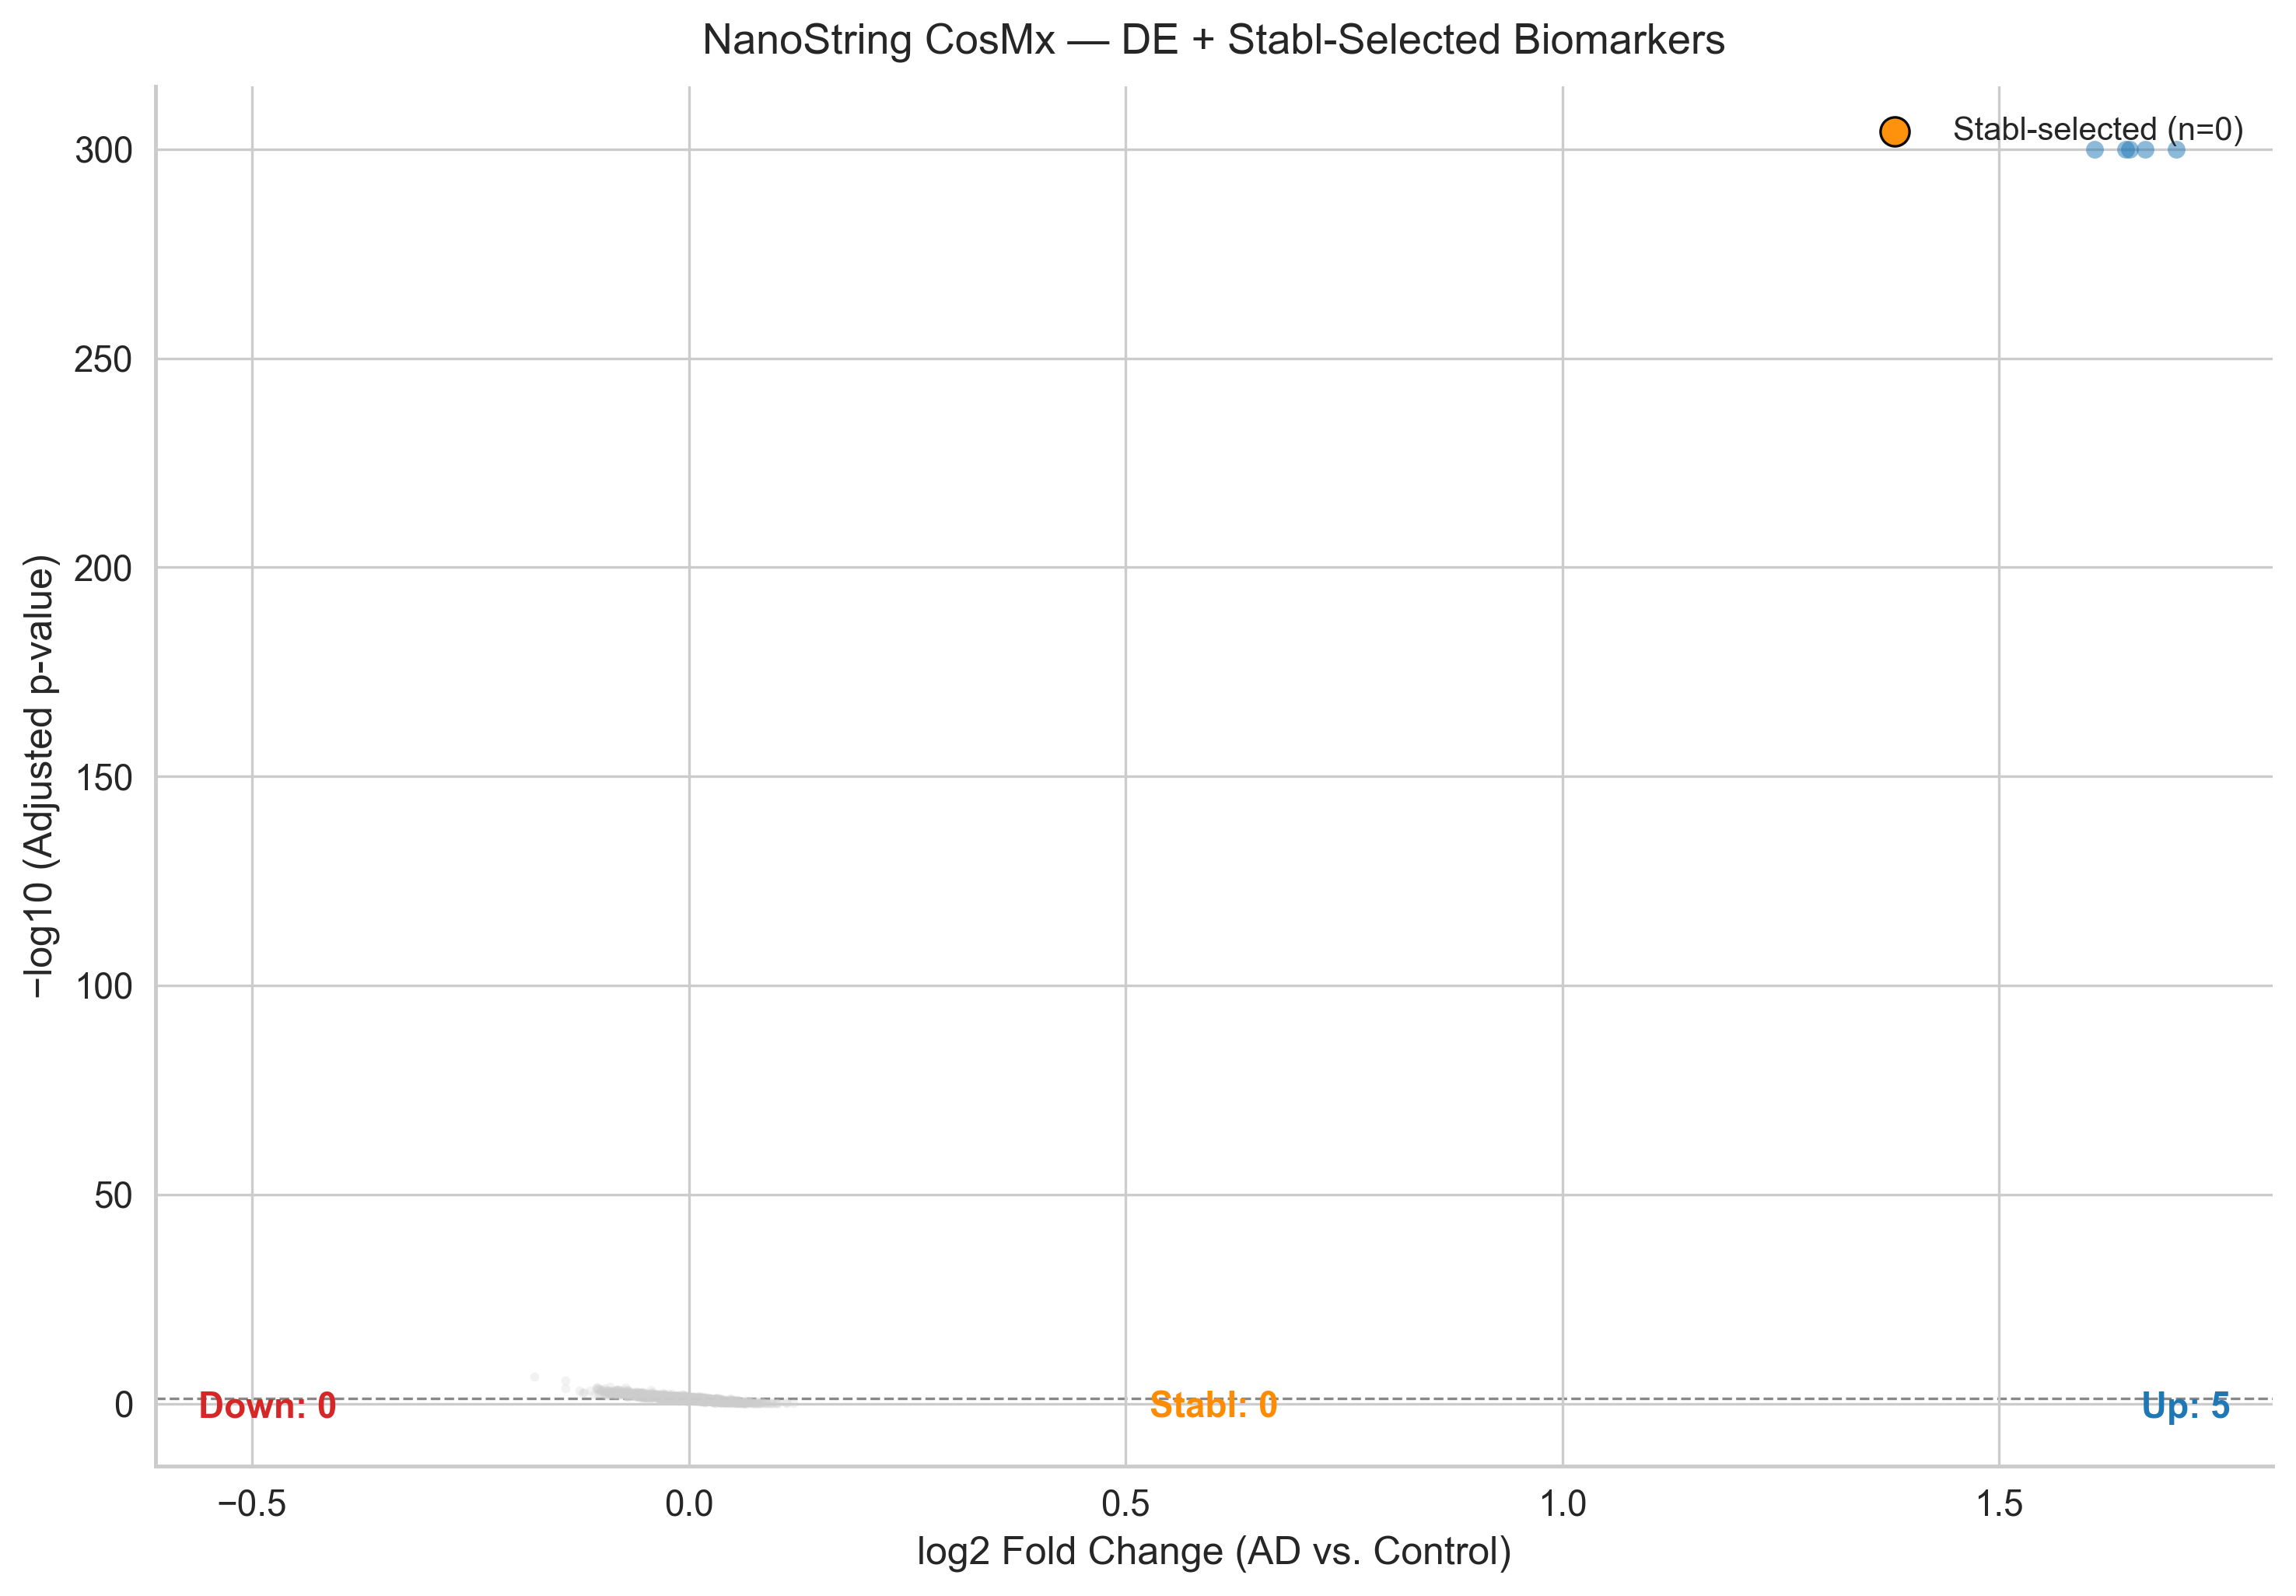

Volcano plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/nanostring_volcano_stabl.png


In [6]:
# Mark Stabl genes in the genome-wide DE table
de_df["is_stabl"] = de_df["gene"].isin(set(stabl_result["selected_genes"]))
n_stabl = de_df["is_stabl"].sum()

# ---------- Volcano Plot 2: DE + Stabl overlay ----------
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

# Background: DE-coloured genes
for cat, zorder in [("ns", 1), ("down", 3), ("up", 3)]:
    sub = de_df[(de_df["sig"] == cat) & ~de_df["is_stabl"]]
    sz = 8 if cat == "ns" else 30
    alpha = 0.25 if cat == "ns" else 0.5
    ax.scatter(
        sub["log2FC"], sub["neg_log10_pval"],
        s=sz, alpha=alpha, c=COLOR_MAP[cat], linewidths=0, zorder=zorder,
    )

# Foreground: Stabl-selected genes
fg = de_df[de_df["is_stabl"]]
ax.scatter(
    fg["log2FC"], fg["neg_log10_pval"], s=80, alpha=0.95, c="#FF8C00",
    linewidths=0.8, edgecolors="black", zorder=10,
    label=f"Stabl-selected (n={n_stabl})",
)

# Annotate Stabl gene names
for _, row in fg.iterrows():
    ax.annotate(
        row["gene"],
        xy=(row["log2FC"], row["neg_log10_pval"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=9, color="#333", fontweight="bold",
    )

# Reference lines
ax.axhline(pval_line, color="#888", ls="--", lw=0.8, zorder=0)
ax.axvline(FC_THR, color="#888", ls=":", lw=0.7, zorder=0)
ax.axvline(-FC_THR, color="#888", ls=":", lw=0.7, zorder=0)

# Counts
ax.text(0.02, 0.03, f"Down: {n_down:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#D62728", va="bottom")
ax.text(0.98, 0.03, f"Up: {n_up:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#1F77B4", va="bottom", ha="right")
ax.text(0.50, 0.03, f"Stabl: {n_stabl}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#FF8C00", va="bottom", ha="center")

ax.set_xlabel("log2 Fold Change (AD vs. Control)", fontsize=12)
ax.set_ylabel("−log10 (Adjusted p-value)", fontsize=12)
ax.set_title("NanoString CosMx — DE + Stabl-Selected Biomarkers", fontsize=13, pad=10)
ax.legend(frameon=False, fontsize=10, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
vol2_path = ASSETS_DIR / "nanostring_volcano_stabl.png"
fig.savefig(vol2_path, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(vol2_path), width=650))
print(f"Volcano plot saved → {vol2_path}")